In [1]:
import sys
sys.path.insert(0, "/teamspace/studios/this_studio/PINNProof/PINNProof")  # change the path to your own path till PINNProof

In [2]:
import torch
import torch.nn as nn
from torchdiffeq import odeint_adjoint as odeint
import matplotlib.pyplot as plt

class SynchronousMachine(nn.Module):
    def __init__(self, 
                 D, P_m,
                 X_d_dash, X_q_dash,
                 X_d, X_q,
                 X_d_dash2, X_q_dash2,
                 H,
                 Rs, Re, Xep,        # <- add Xep to match dataset
                 T_d_dash, T_q_dash,
                 T_d_dd, T_q_dd,
                 E_fd,
                 omega_B=2*torch.pi*50.0):
        super().__init__()
        self.D, self.P_m, self.H = D, P_m, H
        self.X_d_dash, self.X_q_dash = X_d_dash, X_q_dash
        self.X_d, self.X_q = X_d, X_q
        self.X_d_dash2, self.X_q_dash2 = X_d_dash2, X_q_dash2
        self.Rs, self.Re, self.Xep = Rs, Re, Xep
        self.T_d_dash, self.T_q_dash = T_d_dash, T_q_dash
        self.T_d_dd, self.T_q_dd = T_d_dd, T_q_dd
        self.E_fd = E_fd
        self.omega_B = omega_B

        # EXACTLY like data generator: use transient + network (Xep) & Re
        A = torch.tensor([[self.Rs + self.Re,         -(self.X_q_dash + self.Xep)],
                          [ self.X_d_dash + self.Xep,  (self.Rs + self.Re)       ]],
                         dtype=torch.float32)
        self.register_buffer('A_inv', torch.linalg.inv(A))

    def _currents(self, theta, E_d_dash, E_q_dash, V_s, theta_vs):
        v_d = E_d_dash - V_s * torch.sin(theta - theta_vs)
        v_q = E_q_dash - V_s * torch.cos(theta - theta_vs)
        I_d = self.A_inv[0,0]*v_d + self.A_inv[0,1]*v_q
        I_q = self.A_inv[1,0]*v_d + self.A_inv[1,1]*v_q
        return I_d, I_q

    def interface(self, trajectory):
        """
        Given a trajectory tensor of shape (batch, time, 8):
        [δ, ω, E'_d, E'_q, E''_q, E''_d, V_t, θ_vs],
        compute and return (I_D, I_Q), each of shape (batch, time).
        """
        # Extract variables from trajectory
        δ     = trajectory[..., 0]  # Rotor angle
        E_d   = trajectory[..., 2]  # d-axis EMF
        E_q   = trajectory[..., 3]  # q-axis EMF
        V_t   = trajectory[..., 6]  # Terminal voltage magnitude
        θ_vs  = trajectory[..., 7]  # Voltage source phase

        # Compute d/q-axis voltages
        v_d = E_d - V_t * torch.sin(δ - θ_vs)
        v_q = E_q - V_t * torch.cos(δ - θ_vs)

        # Compute d/q-axis currents using inverse impedance matrix
        I_d = self.A_inv[0, 0] * v_d + self.A_inv[0, 1] * v_q
        I_q = self.A_inv[1, 0] * v_d + self.A_inv[1, 1] * v_q

        # Park transformation to D/Q frame (shift by π/2)
        cosρ = torch.cos(δ - torch.pi / 2)
        sinρ = torch.sin(δ - torch.pi / 2)

        I_D = I_d * cosρ - I_q * sinρ
        I_Q = I_d * sinρ + I_q * cosρ

        return I_D, I_Q

    def forward(self, t, y):
        # State ORDER must match your dataset (non-v2):
        # [θ, ω, E′d, E′q, E″d, E″q, V_s, θ_vs]
        theta, omega, E_d_dash, E_q_dash, E_d_dd, E_q_dd, V_s, theta_vs = torch.unbind(y)

        # algebraic currents (transient + Xep + Re)
        I_d, I_q = self._currents(theta, E_d_dash, E_q_dash, V_s, theta_vs)

        # electrical power (same as data gen)
        P_e = (E_d_dash * I_d
               + E_q_dash * I_q
               + (self.X_q_dash - self.X_d_dash) * I_d * I_q)

        # swing
        dtheta_dt = omega                                  # <- NO omega_B here
        domega_dt = (self.omega_B / (2*self.H)) * (self.P_m - P_e - self.D*omega)

        # EMF dynamics (same as odequations non-v2)
        dE_q_dash = (1.0/self.T_d_dash) * (-E_q_dash - (self.X_d - self.X_d_dash)*I_d + self.E_fd)
        dE_d_dash = (1.0/self.T_q_dash) * (-E_d_dash + (self.X_q - self.X_q_dash)*I_q)

        dE_q_dd   = (1.0/self.T_d_dd) * (E_q_dash - E_q_dd + (self.X_d_dash - self.X_d_dash2)*I_d)
        dE_d_dd   = (1.0/self.T_q_dd) * (E_d_dash - E_d_dd - (self.X_q_dash - self.X_q_dash2)*I_q)

        dV_s      = torch.tensor(0.0, device=y.device)
        dtheta_vs = torch.tensor(0.0, device=y.device)

        return torch.stack([dtheta_dt, domega_dt,
                            dE_d_dash, dE_q_dash,
                            dE_d_dd,   dE_q_dd,
                            dV_s,      dtheta_vs])


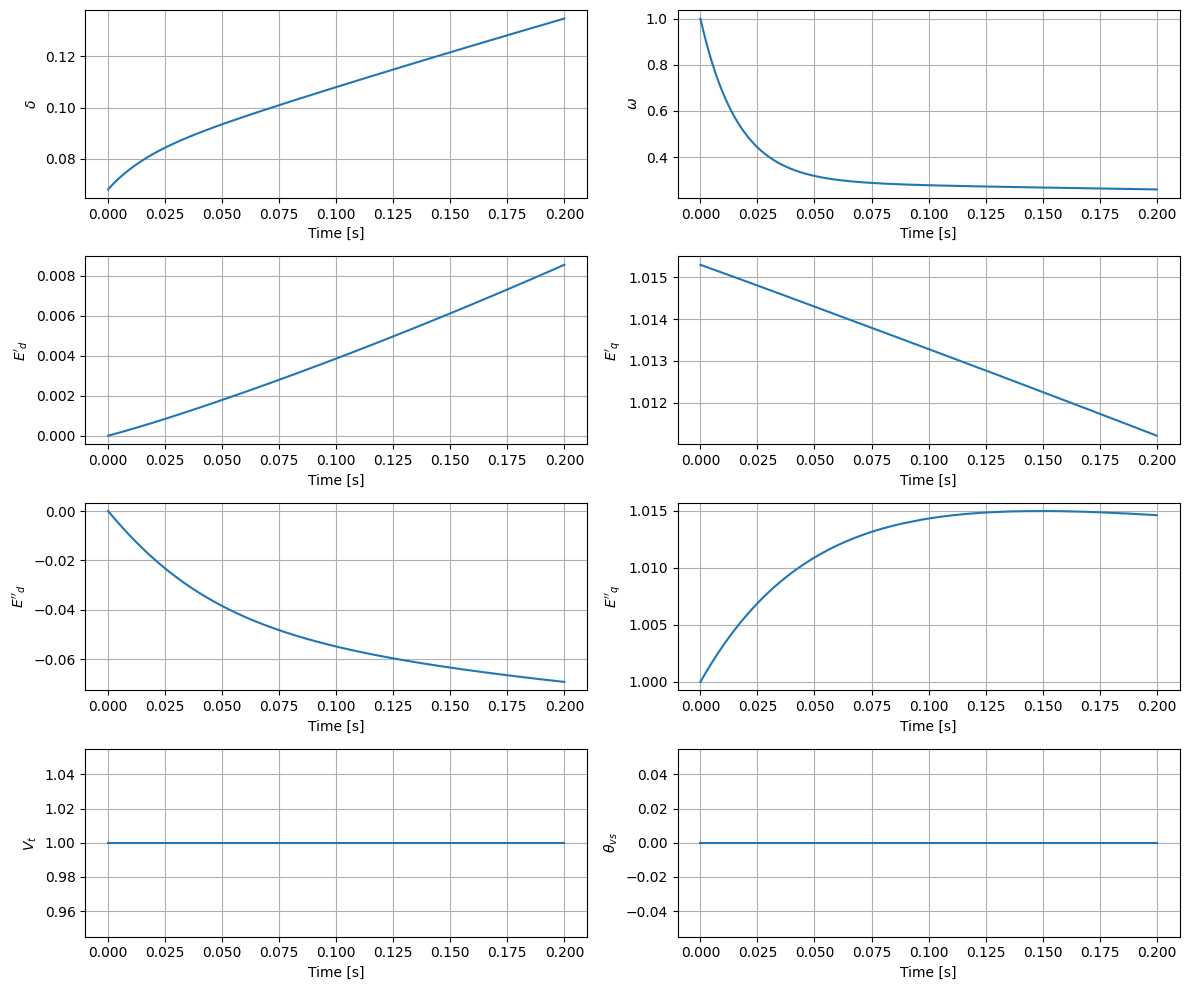

In [3]:
import torch
import matplotlib.pyplot as plt
from torchdiffeq import odeint
from src.solvers.solver import Solver           # your base classes
from src.solvers.ODE_conventional import ODE_conventional

# 1) Time‐vector and constant Vs profile
t_final, num_points = 0.2, 1000
t_tensor = torch.linspace(0., t_final, num_points)
Vs       = torch.ones(num_points)   # 1.0 pu
θs       = torch.zeros(num_points)  # 0 rad
# We'll embed Vs and θs directly into the state, so no extra stack needed here.

# 2) Machine parameters & instantiation
params = {
    'D'         : 2.0,
    'P_m'       : 0.70,
    'X_d'       : 1.25,
    'X_q'       : 1.22,
    'X_d_dash'  : 0.232,
    'X_q_dash'  : 0.715,
    'X_d_dash2' : 0.20,   # X_d''
    'X_q_dash2' : 0.25,   # X_q''
    'H'         : 5.06,
    'Rs'        : 0.0,
    'Re'        : 0.0,
    'T_d_dash'  : 4.75,
    'T_q_dash'  : 1.6,
    'T_d_dd'    : 0.05,   # T_d''
    'T_q_dd'    : 0.04,   # T_q''
    'E_fd'      : 1.0,
    'Xep':0
}

# params = {
#     'D'         : 2,
#     'P_m'       : 0.71,
#     'X_d_dash'  : 0.0608,
#     'X_q_dash'  : 0.0969,
#     'X_d'       : 0.146,
#     'X_q'       : 0.0969,
#     'X_d_dash2' : 0.03,
#     'X_q_dash2' : 0.04,
#     'H'         : 5.06,
#     'Rs'        : 0.0,
#     'Re'        : 0.0,
#     'T_d_dash'  : 8.96,
#     'T_q_dash'  : 0.31,
#     'T_d_dd'    : 0.5,
#     'T_q_dd'    : 0.25,
#     'E_fd'      : 1
# }
# D: 2
# E_fd: 1
# H: 5.06
# P_m: 0.7
# Rs: 0
# T_d_dash: 4.75
# T_q_dash: 1.6
# X_d: 1.25
# X_d_dash: 0.232
# X_q: 1.22
# X_q_dash: 0.715
# X_d_dash_dash: 0.2 #kundur p.153
# T_d_dash_dash: 0.05
# X_q_dash_dash: 0.25
# T_q_dash_dash: 0.04
machine = SynchronousMachine(**params)

# 3) Wrap into your conventional ODE solver
#    forward: (t,y)->dy/dt, interface: (batch, time, 8)->(I_D,I_Q)
solver = ODE_conventional(machine.forward, machine.interface)

# 4) Build the 8-dim initial state [δ₀, ω₀, E′d₀, E′q₀, E″q₀, E″d₀, V_s₀, θ_s₀]
δ0       = 0.0680
ω0       = 0.0
E_d0     = 0.0
E_q0     = 1.0153
E_q_dd0  = 1.0
E_d_dd0  = 0.0
V_s0     = Vs[0].item()   # 1.0
θ_s0     = θs[0].item()   # 0.0
# x0 = torch.tensor([δ0, ω0, E_d0, E_q0,E_d_dd0, E_q_dd0, V_s0, θ_s0],
#                   dtype=torch.float32)
x0 = [0.0680, 1.0, 0.0, 1.0153, 0.0, 1.0, 1.0, 0.0]

# 5) Solve!
t_sol, sol = solver.solve(x0, t_final, num_points)
# sol has shape (num_points, 8)

# 6) Extract rotor states
delta  = sol[:, 0]
omega  = sol[:, 1]
E_d    = sol[:, 2]
E_q    = sol[:, 3]

#import matplotlib.pyplot as plt

# assume t_sol (num_points,) and sol (num_points, 8) are from your solver
# sol[:,i] corresponds to:
labels = [
    r"$\delta$",
    r"$\omega$",
    r"$E'_d$",
    r"$E'_q$",
    r"$E''_d$",
    r"$E''_q$",
    r"$V_t$",
    r"$\theta_{vs}$"
]

fig, axs = plt.subplots(4, 2, figsize=(12, 10))
axs = axs.flatten()

for i in range(8):
    axs[i].plot(t_sol, sol[:, i].detach())
    axs[i].set_ylabel(labels[i])
    axs[i].set_xlabel("Time [s]")
    axs[i].grid(True)

plt.tight_layout()
plt.show()


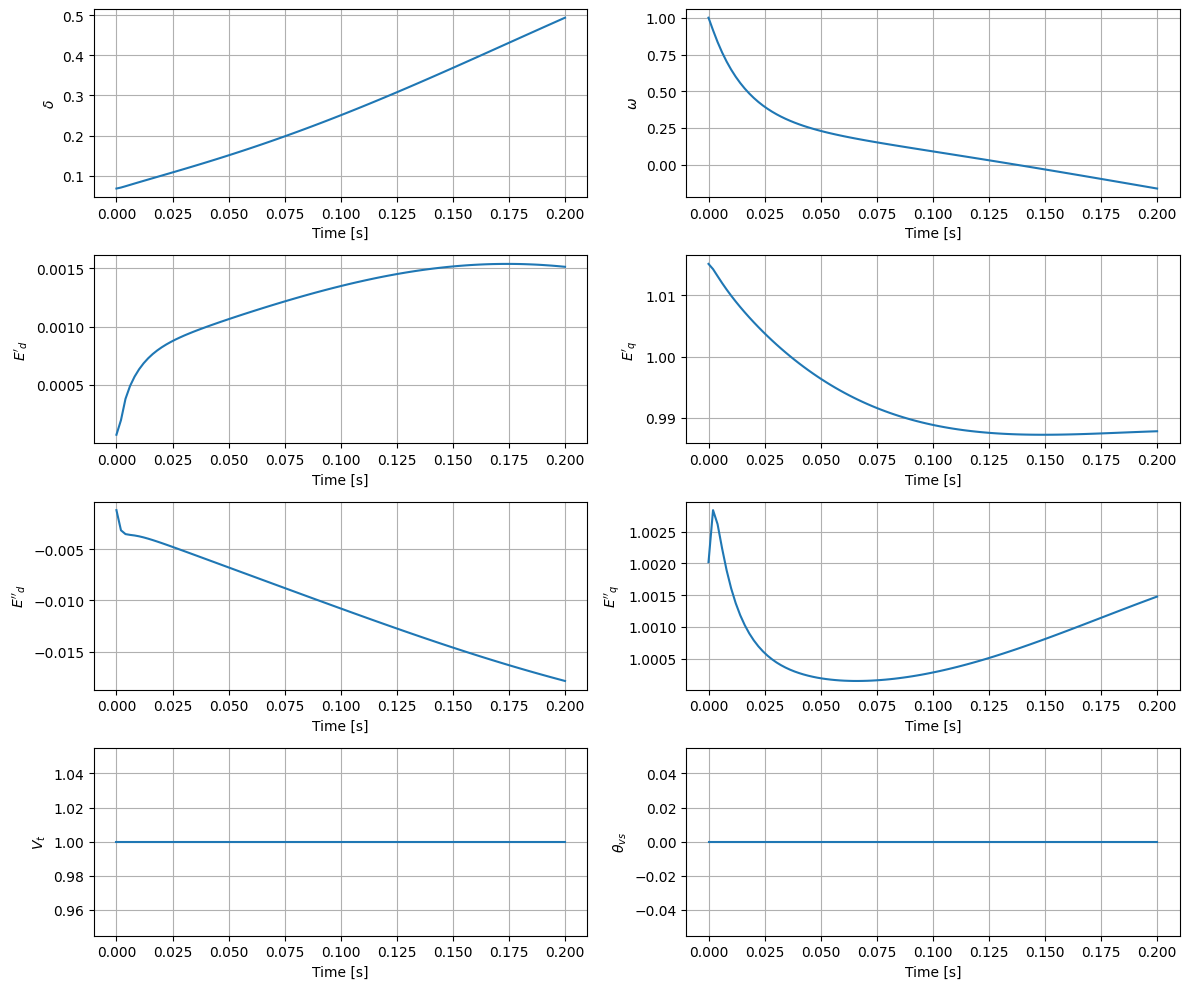

In [11]:
# # V_profile.shape
# import torch
# import matplotlib.pyplot as plt

# # -------------------------------------------------------------
# # 1) Non-iterative rollout with the current PINN (outputs=states)
# #    Model input is [t, δ0, ω0, E′d0, E′q0, E″d0, E″q0, V_t(t), θ_vs(t)]
# # -------------------------------------------------------------
# def rollout_pinn_states(model, t, y0_8, Vt, thetavs, device=None):
#     """
#     model:   your Network (states output)
#     t:       (T,) time in seconds
#     y0_8:    list/1D tensor of length 8 -> [δ0, ω0, E′d0, E′q0, E″d0, E″q0, V_t0, θ_vs0]
#              NOTE: we will overwrite V_t, θ_vs with the time profiles below.
#     Vt:      (T,) profile for V_t
#     thetavs: (T,) profile for θ_vs
#     """
#     device = device or next(model.parameters()).device
#     T = t.numel()

#     # Build input rows [t_k, y0(6 states + 2 controls)]
#     y0 = torch.as_tensor(y0_8, dtype=torch.float32)
#     # replace controls with time-varying ones
#     y0 = y0.clone()
#     y0_states = y0[:6]  # δ0, ω0, E′d0, E′q0, E″d0, E″q0

#     t_in   = t.to(torch.float32).view(T, 1).to(device)
#     Vt_in  = Vt.to(torch.float32).view(T, 1).to(device)
#     th_in  = thetavs.to(torch.float32).view(T, 1).to(device)
#     y0_in  = y0_states.to(device).repeat(T, 1)                      # (T,6)
#     ctrl   = torch.cat([Vt_in, th_in], dim=1)                       # (T,2)
#     x_in   = torch.cat([t_in, y0_in, ctrl], dim=1)                  # (T, 1+6+2=9)
#     print(x_in)
#     model.eval()
#     with torch.no_grad():
#         Y = model(x_in)                                             # (T,6) -> [δ, ω, E′d, E′q, E″d, E″q]
#     # Pack back 8 vars (append controls actually used)
#     Y8 = torch.cat([Y, ctrl], dim=1)                                # (T,8)
#     return Y8

# # Example use with your profiles and ICs
# t_final, num_points = 0.2, 1000
# t_tensor = torch.linspace(0., t_final, num_points)
# Vs       = torch.ones(num_points)
# θs       = torch.zeros(num_points)
# y0 = [0.0680, 0.0, 1.0, 0.0,1.0153, 0.0, Vs[0].item(), θs[0].item()]  # note: ω0=0.0 means dev=0 only if your model uses ω as deviation!

# with torch.no_grad():
#     Y_pred = rollout_pinn_states(model, t_tensor, y0, Vs, θs, device=device)  # (T,8)

# # Plot
# labels = [r"$\delta$", r"$\omega$", r"$E'_d$", r"$E'_q$", r"$E''_d$", r"$E''_q$", r"$V_t$", r"$\theta_{vs}$"]
# fig, axs = plt.subplots(4, 2, figsize=(12, 10))
# axs = axs.flatten()
# for i in range(8):
#     axs[i].plot(t_tensor.cpu(), Y_pred[:, i].cpu())
#     axs[i].set_ylabel(labels[i]); axs[i].set_xlabel("Time [s]"); axs[i].grid(True)
# plt.tight_layout(); plt.show()
# -------------------------------------------------------------
# Iterative rollout (closed loop): y_{k+1|k} = model(t_k, y_k, u_k)
# Model input: [t_k, δ_k, ω_k, E′d_k, E′q_k, E″d_k, E″q_k, V_t(k), θ_vs(k)]
# Model output: [δ_{k+1}, ω_{k+1}, E′d_{k+1}, E′q_{k+1}, E″d_{k+1}, E″q_{k+1}]
# -------------------------------------------------------------
def rollout_pinn_states_iterative(model, t, y0_8, Vt, thetavs, use_delta_t=False, device=None):
    """
    model:    NN that maps [time_feature, 6 states, 2 controls] -> 6 next states
    t:        (T,) time stamps (seconds)
    y0_8:     list/1D tensor len=8: [δ0, ω0, E′d0, E′q0, E″d0, E″q0, V_t0, θ_vs0]
    Vt:       (T,) profile for V_t
    thetavs:  (T,) profile for θ_vs
    use_delta_t: if True, feed Δt_k instead of absolute t_k (often more stable)
    returns:  (T, 8) with states (6) + controls (2) for each step
    """
    device = device or next(model.parameters()).device
    t        = t.to(device).float()
    Vt       = Vt.to(device).float()
    thetavs  = thetavs.to(device).float()

    T = t.numel()
    y0 = torch.as_tensor(y0_8, dtype=torch.float32, device=device)
    y_prev_states = y0[:6].clone()   # δ, ω, E′d, E′q, E″d, E″q

    # Buffer for outputs
    Y_pred = torch.zeros(T, 6, device=device)
    U_used = torch.zeros(T, 2, device=device)

    model.eval()
    with torch.no_grad():
        for k in range(T):
            # time feature: either absolute t_k or Δt_k
            if use_delta_t:
                if k == 0:
                    time_feat = torch.tensor([0.0], device=device)  # Δt_0 = 0
                else:
                    time_feat = (t[k] - t[k-1]).view(1)             # Δt_k
            else:
                time_feat = t[k].view(1)                            # t_k

            u_k = torch.stack([Vt[k], thetavs[k]]).view(2)          # (2,)

            # Build input row [time_feature, states_k, controls_k] -> shape (9,)
            x_k = torch.cat([time_feat, y_prev_states, u_k], dim=0).view(1, -1)

            # Predict next states
            y_next = model(x_k).view(-1)                            # (6,)
            Y_pred[k] = y_next
            U_used[k] = u_k
            y_prev_states = y_next                                  # closed loop: feed back

    # Pack back 8 vars (append controls actually used)
    Y8 = torch.cat([Y_pred, U_used], dim=1)                         # (T,8)
    return Y8

# ---------- Example usage ----------
t_final, num_points = 0.2, 100
t_tensor = torch.linspace(0., t_final, num_points)
Vs       = torch.ones(num_points)
θs       = torch.zeros(num_points)
# y0 = [0.0680, 0.0, 1.0, 0.0, 1.0153, 0.0, Vs[0].item(), θs[0].item()]
y0 = [0.0680, 1.0, 0.0, 1.0153, 0.0, 1.0, 1.0, 0.0]

with torch.no_grad():
    # set use_delta_t=True if your model was trained on step sizes rather than absolute time
    Y_iter = rollout_pinn_states_iterative(model, t_tensor, y0, Vs, θs, use_delta_t=True, device=device)

# Plot (same as before)
labels = [r"$\delta$", r"$\omega$", r"$E'_d$", r"$E'_q$", r"$E''_d$", r"$E''_q$", r"$V_t$", r"$\theta_{vs}$"]
fig, axs = plt.subplots(4, 2, figsize=(12, 10)); axs = axs.flatten()
for i in range(8):
    axs[i].plot(t_tensor.cpu(), Y_iter[:, i].cpu())
    axs[i].set_ylabel(labels[i]); axs[i].set_xlabel("Time [s]"); axs[i].grid(True)
plt.tight_layout(); plt.show()


In [8]:
# Define initial‐condition ranges for every state in [δ, ω, E′d, E′q, E″q, E″d, V_t, θ_vs]
ic_ranges = {
    'delta'     : (-2,  2),   # rotor angle [rad]
    'omega'     : (-1, 1),   # speed deviation [pu]
    'E_d_dash'  : (0.0,   0.0),   # transient d‐axis emf fixed
    'E_q_dash'  : (1.0,   1.0),   # transient q‐axis emf fixed
    'E_q_dd'    : (0.0,   0.0),   # subtransient q‐axis emf fixed
    'E_d_dd'    : (1.0,   1.0),   # subtransient d‐axis emf fixed
    'V_t'       : (0.95,   1.05),   # terminal voltage magnitude [pu]
    'theta_vs'  : (-0.3,  0.3),   # terminal voltage angle [rad]
}
# - {name: theta, range: [-2, 2], iterations: 7}
# - {name: omega, range: [-1, 1], iterations: 7}
# - {name: E_d_dash, range: [0], iterations: 1}
# - {name: E_q_dash, range: [0.9, 1.1], iterations: 5}
# - {name: E_d_dash_dash, range: [0], iterations: 1}
# - {name: E_q_dash_dash, range: [1], iterations: 1}
# - {name: Vs, range: [0.95,1.05], iterations: 3}
# - {name: theta_vs, range: [-0.3,0.3], iterations: 4}

t, data, ics = solver.generate_dataset(
    ic_ranges=ic_ranges,
    num_ic=100,
    t_final=t_final,
    num_points=num_points
)


/teamspace/studios/this_studio/PINNProof/PINNProof/src/solvers/ODE_conventional.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ini_cond = torch.tensor(ini_cond, dtype=torch.float32)


In [9]:
I_D, I_Q = solver.interface(data)


In [10]:
import os
os.getcwd()
# Change to a new directory  
os.chdir("./PINNProof/PINNProof/")  
print("After Changing:", os.getcwd())
from pretrained_models.architectures import Network


FileNotFoundError: [Errno 2] No such file or directory: './PINNProof/PINNProof/'

In [7]:
model=Network(input_size=9, hidden_size=64, output_size=6, num_layers=3,activation="tanh")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model_path = "examples/pretrained_models/SM6_LBFGS_seed7.pth"
# model_path = "examples/pretrained_models/SM6DynamicNN_0.2s_with_data.pth"
model_path = "examples/pretrained_models/SM6DynamicNN_0.2s_with_data1.pth"

# model_path = "examples/pretrained_models/SM6DynamicNN_0.2s_only_pinn.pth"
model_data = torch.load(model_path, weights_only=True, map_location=device)
# Check if model_data contains the key 'model_state_dict'
if isinstance(model_data, dict) and 'model_state_dict' in model_data:
    state_dict = model_data['model_state_dict']
else:
    state_dict = model_data
    print(state_dict)
    print("Model state keys:", state_dict.keys())
    print("Expected model keys:", model.state_dict().keys())
model.load_state_dict(state_dict)

<All keys matched successfully>

In [6]:
from src.solvers.solver_nn import *

In [7]:
sample_solver_nn = Solver_NN(func=machine.forward, n_control=2, n_states=6, model=model)  # assuming states=6 for SM6, hence control=2 since number of inputs is 9

In [49]:
t, Y = sample_solver_nn.solve(ini_cond=[0.2, 0.3, -0.4, 0.1, 0.0, 0.6, 0.8, -0.18], t_final=2.0, num_points=100)  # random sample initial conditions, 8 in number excluding time variable
print(t.shape)
print(Y.shape)

(100,)
(100, 6)


In [50]:
# bounds_for_sampling

In [51]:
# # Find the residuals from this nn_solver object
# R = sample_solver_nn.compute_residuals(bounds=bounds_for_sampling, num_trajectories=17, num_points=130)
# print(R.shape)

In [52]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def _edges_from_centers(x):
    """Compute bin edges from sorted centers (non-uniform OK)."""
    x = np.asarray(x)
    if x.size == 1:
        # single row: make a small band around it
        return np.array([x[0]-0.5, x[0]+0.5])
    mid = 0.5*(x[:-1] + x[1:])
    first = x[0] - (mid[0] - x[0])
    last  = x[-1] + (x[-1] - mid[-1])
    return np.concatenate(([first], mid, [last]))

def _time_edges(t0, t1, T):
    t = np.linspace(t0, t1, T)
    if T == 1:
        return np.array([t0-0.5, t1+0.5])
    dt = np.diff(t)
    left  = t[0] - dt[0]/2
    right = t[-1] + dt[-1]/2
    mids  = 0.5*(t[:-1] + t[1:])
    return np.concatenate(([left], mids, [right]))

def plot_residual_heatmaps_by_state_y(
    R,                    # (N, T, S) tensor/array
    y0s,                  # (N, 8) ICs; first 6 are the states
    t_bounds,             # (t0, t1)
    state_labels=None,    # list of S labels
    log_scale=True,
    eps=1e-12
):
    # to numpy
    if isinstance(R, torch.Tensor): R = R.detach().cpu().numpy()
    if isinstance(y0s, torch.Tensor): y0s = y0s.detach().cpu().numpy()
    N, T, S = R.shape
    assert y0s.shape[0] == N, "y0s must have N rows to match R."

    if state_labels is None:
        state_labels = [r"$\delta$", r"$\omega$", r"$E'_d$", r"$E'_q$", r"$E''_q$", r"$E''_d$"]

    t0, t1 = t_bounds
    t_edges = _time_edges(t0, t1, T)

    # choose magnitude (log or linear)
    if log_scale:
        Rplot = np.log10(np.abs(R) + eps)
        cbar_label = r"$\log_{10}(|\mathrm{residual}|)$"
    else:
        Rplot = R
        cbar_label = "residual"

    for s in range(S):
        # y-axis = IC of state s
        yvals = y0s[:, s]
        order = np.argsort(yvals)
        y_sorted = yvals[order]
        Z = Rplot[order, :, s]                      # (N, T)

        y_edges = _edges_from_centers(y_sorted)     # (N+1,)

        plt.figure(figsize=(8, 4))
        # pcolormesh expects Z shape (len(y_edges)-1, len(t_edges)-1)
        plt.pcolormesh(t_edges, y_edges, Z, shading='auto')
        plt.colorbar(label=cbar_label)
        plt.xlabel("Time [s]")
        plt.ylabel(f"IC of {state_labels[s]}")
        plt.title(f"Residual heatmap vs time (y = {state_labels[s]})")
        plt.tight_layout()
        plt.show()


tensor([[-43.5463],
        [-43.2853],
        [-43.1241],
        ...,
        [  1.2778],
        [  1.2761],
        [  1.2748]], grad_fn=<SubBackward0>)


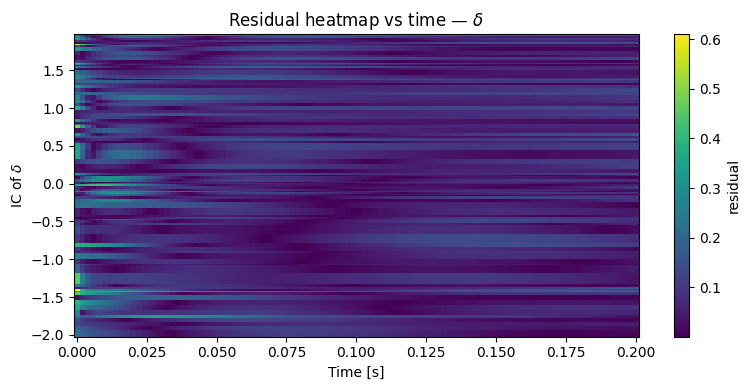

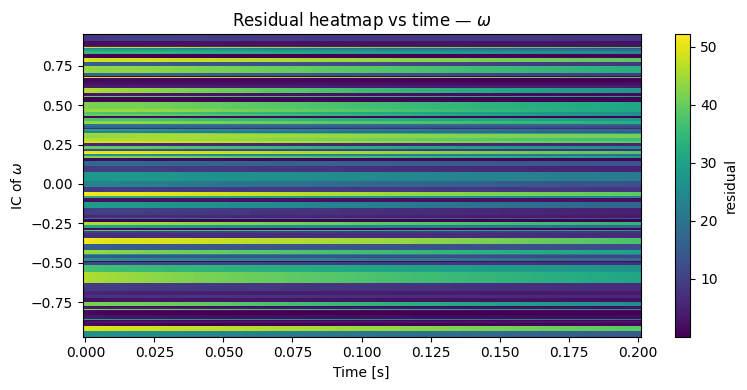

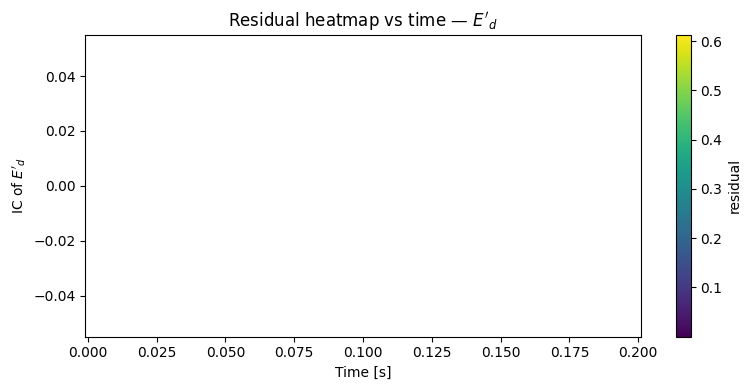

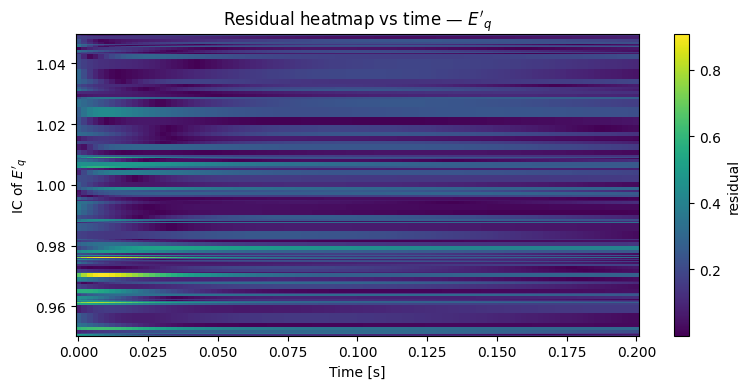

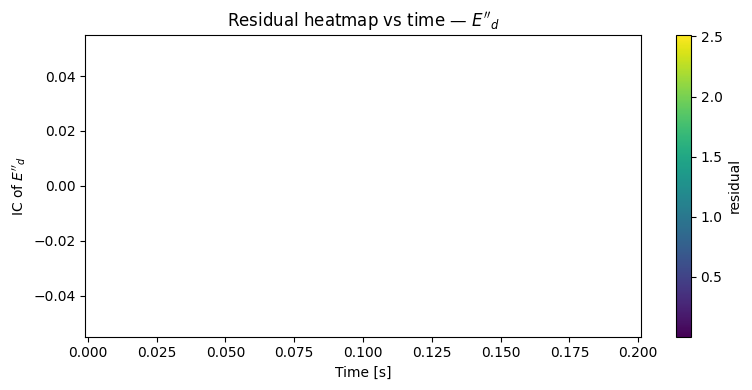

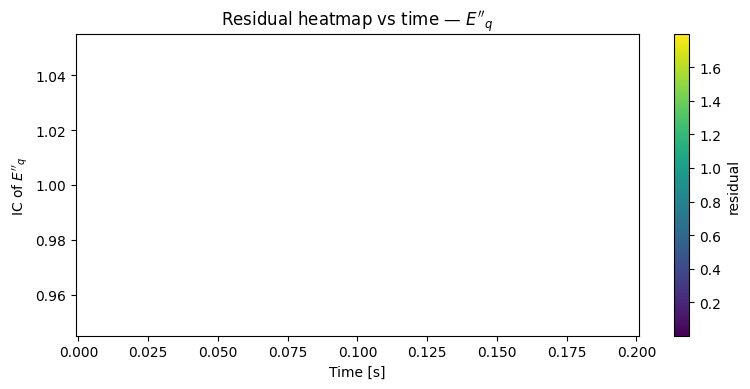

In [54]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import os
from pathlib import Path

def pinn_residual_heatmaps_by_state_y(
    solver,                    # your Solver_NN (needs .model, .func, .n_states, .generate_batched_samples)
    bounds,                    # dict with keys for 8 states + 't'
    num_trajectories: int,
    num_points: int,
    *,
    outputs_are_slopes: bool = False,
    state_labels = (r"$\delta$", r"$\omega$", r"$E'_d$", r"$E'_q$", r"$E''_d$", r"$E''_q$"),
    log10: bool = False,
    eps: float = 1e-12,
    save_dir: str | None = None,
):
    """
    Computes residuals r = dy/dt - f(t,y) and plots one heatmap per state:
      x-axis: time, y-axis: IC value of the SAME state, color: residual magnitude.
    Returns (R, y0s): residual tensor (N,T,S) and the IC matrix (N,8).
    """
    def _edges_from_centers(x):
        x = np.asarray(x)
        if x.size == 1:
            return np.array([x[0] - 0.5, x[0] + 0.5])
        mid = 0.5 * (x[:-1] + x[1:])
        first = x[0] - (mid[0] - x[0])
        last  = x[-1] + (x[-1] - mid[-1])
        return np.concatenate(([first], mid, [last]))

    def _time_edges(t0, t1, T):
        t = np.linspace(t0, t1, T)
        if T == 1:
            return np.array([t0 - 0.5, t1 + 0.5])
        mids = 0.5 * (t[:-1] + t[1:])
        left  = t[0]  - (mids[0] - t[0])
        right = t[-1] + (t[-1] - mids[-1])
        return np.concatenate(([left], mids, [right]))

    # ------------------ sample ICs/time exactly once ------------------
    var_names = [k for k in bounds.keys() if k != 't']  # keep your order
    y0s, t_grid = solver.generate_batched_samples(bounds, var_names, num_trajectories, num_points)
    # Model device for autograd; func (machine.forward) will be run on CPU
    model_device = next(solver.model.parameters()).device

    y0s = y0s.to(model_device)
    t_grid = t_grid.to(model_device)

    # Flatten time (enable grad)
    t_vec = t_grid.reshape(-1, 1).clone().detach().requires_grad_(True)     # (N*T,1)
    # Repeat ICs per time step
    y0s_vec = y0s.repeat_interleave(num_points, dim=0)                       # (N*T, 8)

    # Split states/controls
    S = solver.n_states
    y0_states_vec = y0s_vec[:, :S]                                           # (N*T, 6)
    y0_ctrl_vec   = y0s_vec[:, S:] if y0s_vec.shape[1] > S else None         # (N*T, 2) or None
    # print(y0_states_vec,y0_ctrl_vec)
    # ------------------ forward PINN ------------------
    # Model input matches your solve(): [t, y0(8)]
    model_input = torch.cat([t_vec, y0s_vec], dim=1)                         # (N*T, 9)
    solver.model.eval()
    net_out = solver.model(model_input)                                      # (N*T, 6)

    # Reconstruct y(t)
    # if outputs_are_slopes:
    #     y_hat = y0_states_vec + net_out * t_vec                              # slopes -> states
    # else:
    y_hat = net_out                                                      # states directly

    # ------------------ dy/dt (per state) ------------------
    grads = []
    for k in range(S):
        gk = torch.autograd.grad(
            outputs=y_hat[:, k:k+1],
            inputs=t_vec,
            grad_outputs=torch.ones_like(y_hat[:, k:k+1]),
            create_graph=True,
            retain_graph=True #(k < S - 1)
        )[0]                                                                 # (N*T,1)
        grads.append(gk)
    dy_dt = torch.cat(grads, dim=1)                                          # (N*T,6)

    # ------------------ RHS f(t,y) on CPU (robust to device mix) ------------------
    # Detach y and move to CPU for machine.forward(t,y)
    y_hat_cpu   = y_hat.detach().cpu()
    y0_ctrl_cpu = y0_ctrl_vec.detach().cpu() if y0_ctrl_vec is not None else None
    y_full_cpu  = torch.cat([y_hat_cpu, y0_ctrl_cpu], dim=1) if y0_ctrl_cpu is not None else y_hat_cpu
    t_cpu       = t_vec.detach().cpu().squeeze(-1)

    f_list = []
    with torch.no_grad():
        for i in range(y_full_cpu.shape[0]):
            fi = solver.func(t_cpu[i], y_full_cpu[i])                        # (8,)
            f_list.append(fi)
    f_full = torch.stack(f_list, dim=0).to(dy_dt.dtype)                      # (N*T,8) on CPU
    f_val  = f_full[:, :S].to(model_device)                                  # back to model device

    # ------------------ residuals and reshape ------------------
    print(f_val[:,1:2]-dy_dt[:,1:2])
    R = (dy_dt - f_val).view(num_trajectories, num_points, S)                # (N,T,6)
    R_np   = R.detach().cpu().numpy()
    y0s_np = y0s.detach().cpu().numpy()

    # ------------------ plot heatmaps ------------------
    t0, t1 = bounds['t']
    t_edges = _time_edges(t0, t1, num_points)

    if log10:
        Z_title = r"$\log_{10}(|\mathrm{residual}|)$"
    else:
        Z_title = "residual"

    if save_dir is not None:
        Path(save_dir).mkdir(parents=True, exist_ok=True)

    for s in range(S):
        # y-axis = IC of state s
        yvals   = y0s_np[:, s]                       # (N,)
        order   = np.argsort(yvals)
        y_sorted= yvals[order]
        Z       = R_np[order, :, s]
        # Zplot =np.abs(Z)
        Zplot   = np.log10(np.abs(Z) + eps) if log10 else np.abs(Z)
        y_edges = _edges_from_centers(y_sorted)

        plt.figure(figsize=(8, 4))
        plt.pcolormesh(t_edges, y_edges, Zplot, shading='auto')
        plt.colorbar(label=Z_title)
        plt.xlabel("Time [s]")
        plt.ylabel(f"IC of {state_labels[s]}")
        plt.title(f"Residual heatmap vs time — {state_labels[s]}")
        plt.tight_layout()
        if save_dir:
            plt.savefig(os.path.join(save_dir, f"residual_heatmap_{s}.png"), dpi=200)
        plt.show()

    return R, y0s_np
bounds_for_sampling= {
    't':(0,0.2),
    'delta'     : (-2,  2),   # rotor angle [rad]
    'omega'     : (-1.0, 1),   # speed deviation [pu]
    'E_d_dash'  : (0.0,   0.0),   # transient d‐axis emf fixed
    'E_q_dash'  : (0.95,   1.05),   # transient q‐axis emf fixed
    'E_d_dd'    : (0.0,   0.0),   # subtransient q‐axis emf fixed
    'E_q_dd'    : (1.0,   1.0),   # subtransient d‐axis emf fixed
    'V_t'       : (0.95,   1.05),   # terminal voltage magnitude [pu]
    'theta_vs'  : (-0.3,  0.3),   # terminal voltage angle [rad]
}
R, y0s = pinn_residual_heatmaps_by_state_y(
    solver=sample_solver_nn,
    bounds=bounds_for_sampling,       # includes 't': (0.0, t_final)
    num_trajectories=100,
    num_points=100,
    outputs_are_slopes=False,         # set True if your net outputs slopes
    save_dir=None                     # or "figs/residuals"
)


In [39]:
y0s

array([[ 1.3034484 ,  0.09882808,  0.        , ...,  1.        ,
         1.0078926 ,  0.20193571],
       [-1.2355187 ,  0.11719954,  0.        , ...,  1.        ,
         1.0474932 , -0.1344506 ],
       [-1.7772071 , -0.5981866 ,  0.        , ...,  1.        ,
         1.0408026 , -0.13606071],
       ...,
       [-0.450186  , -0.50832534,  0.        , ...,  1.        ,
         0.96961856, -0.03987896],
       [ 1.6923239 , -0.7370213 ,  0.        , ...,  1.        ,
         1.0467942 ,  0.05628791],
       [ 0.60667634,  0.55278444,  0.        , ...,  1.        ,
         1.0376488 , -0.01045111]], dtype=float32)

In [ ]:
f_full

In [38]:
R

tensor([[[-1.6740e-01,  2.3608e+01, -1.4340e-01, -3.8959e-01,  2.1470e+00,
          -4.8814e-01],
         [-1.4286e-01,  2.3418e+01, -9.3177e-02, -3.4076e-01,  2.0143e+00,
          -6.1721e-01],
         [-1.2277e-01,  2.3330e+01, -5.2375e-02, -3.0230e-01,  1.9069e+00,
          -7.1082e-01],
         ...,
         [-8.4163e-02,  1.5972e+01, -9.4445e-02, -2.0718e-03,  1.4685e+00,
          -2.9606e-01],
         [-8.3290e-02,  1.5890e+01, -9.7044e-02, -6.7287e-03,  1.4642e+00,
          -2.9319e-01],
         [-8.2380e-02,  1.5807e+01, -9.9649e-02, -1.1352e-02,  1.4599e+00,
          -2.9027e-01]],

        [[-5.1685e-02, -1.9878e+01,  1.2835e-01,  4.6816e-01, -1.7306e+00,
          -9.7545e-02],
         [-1.0635e-01, -2.0269e+01,  6.5479e-02,  4.6847e-01, -1.8352e+00,
           1.4213e-02],
         [-1.2884e-01, -2.0411e+01,  2.5382e-02,  4.6072e-01, -1.8539e+00,
           4.3357e-02],
         ...,
         [ 3.5644e-02, -1.1314e+01,  4.1380e-02,  7.0738e-02, -1.5608e+00,
    